# Day 1 - Exploratory Data Analysis: From Question to Decision

One notebook. One dataset. One complete journey through the Data Science lifecycle.

**Dataset:** Student Performance (carries across all 5 days)

```
Part A: Setting the Stage (AI World, Data Science Overview)
Part B: Python Essentials Quick Tour (NumPy, Pandas)
Part C: The Lifecycle in Action
   Step 5:  Problem Understanding
   Step 6:  Data Collection
   Step 7:  Data Understanding / Inspection
   Step 8:  Data Cleaning
   Step 9:  Exploratory Data Analysis
   Step 10: Statistics
   Step 11: Visualization
   Step 12: Feature Preparation
   Step 13: Communication & Decision
```

**Rule:** Start with the question, not the tool.

---
## Step 0: Setup

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

print("Libraries ready.")

Libraries ready.


---
# Part A: Setting the Stage

---
## Step 1: The AI World

### Why did AI suddenly become powerful?

Three forces came together:

| Force | What changed |
|---|---|
| **Big Data** | Internet, sensors, and phones generate massive amounts of data |
| **Algorithms** | Better mathematical methods (deep learning, transformers) |
| **Computing** | GPUs and cloud computing made training large models affordable |

None of these alone was enough. The explosion happened when all three matured at the same time.

### The AI Family Tree

```
Rule-Based Systems (1950s-80s)
  Hand-written IF-THEN rules. Brittle, couldn't handle ambiguity.
      |
Machine Learning (1990s-2010s)
  Learn patterns from data instead of writing rules.
  Examples: Linear regression, Decision trees, SVM, Random Forest
      |
Deep Learning (2012+)
  Neural networks with many layers. Learns complex patterns.
  Examples: Image recognition, Speech-to-text, Self-driving
      |
Generative AI (2022+)
  Creates new content: text, images, code, music.
  Examples: ChatGPT, Claude, DALL-E, Midjourney
      |
Agentic AI (2024+)
  AI that can plan, use tools, and take actions autonomously.
  Examples: AI coding agents, research agents, workflow automation
```

Each generation builds on the previous one - they don't replace each other.

### Data Science vs AI

| | Data Science | AI |
|---|---|---|
| **Goal** | Extract insights and inform decisions | Build systems that act intelligently |
| **Focus** | Understanding data, finding patterns | Automating decisions and actions |
| **Output** | Reports, dashboards, recommendations | Models, predictions, autonomous agents |
| **Overlap** | Both use statistics, ML, and programming |

Data Science often feeds into AI. Today we learn the Data Science foundations.

---
## Step 2: What is Data Science?

**Data Science** is the practice of extracting meaningful insights from data to support decisions.

It combines: **domain knowledge + statistics + programming**

### The Data Science Lifecycle

Every DS project follows a lifecycle. Here are all the steps:

| # | Step | What happens | Today? |
|---|---|---|---|
| 1 | Problem Understanding | Define the business question | Yes |
| 2 | Data Collection | Gather data from sources | Yes |
| 3 | Data Understanding | Inspect structure, types, quality | Yes |
| 4 | Data Cleaning | Fix errors, missing values, duplicates | Yes |
| 5 | EDA | Explore patterns, distributions, groups | Yes |
| 6 | Statistics | Summarize with numbers (mean, std, corr) | Yes |
| 7 | Visualization | Charts that reveal patterns | Yes |
| 8 | Feature Preparation | Scale, encode, create new features | Yes |
| 9 | Modeling | Train ML models to predict/classify | Day 2-3 |
| 10 | Evaluation | Measure model accuracy and fairness | Day 2-3 |
| 11 | Tuning | Improve model performance | Day 4 |
| 12 | Deployment | Put model into production | Day 5 |
| 13 | Monitoring | Track performance over time | Day 5 |

**Key insight:** Data Science is **iterative**, not linear. You will go back and forth between steps. Cleaning reveals new questions. Modeling failures send you back to feature preparation. This is normal.

Today we cover Steps 1-8 + Communication. Days 2-5 build on today's cleaned dataset.

---
# Part B: Python Essentials Quick Tour

Before diving into the lifecycle, let's review the two essential libraries for data science in Python.

---
## Step 3: NumPy Essentials

**NumPy** = Numerical Python. The foundation for all scientific computing in Python.

Why NumPy? Regular Python lists are slow for math. NumPy arrays are fast and designed for calculations.

In [74]:
# Creating arrays
marks = np.array([72, 85, 90, 68, 95, 78, 88])
print("Array:", marks)
print("Type:", type(marks))
print("Shape:", marks.shape)

Array: [72 85 90 68 95 78 88]
Type: <class 'numpy.ndarray'>
Shape: (7,)


In [75]:
# Element-wise operations (no loops needed!)
print("Add 5 to each:", marks + 5)
print("Double each:", marks * 2)
print("Above 80:", marks[marks > 80])

Add 5 to each: [ 77  90  95  73 100  83  93]
Double each: [144 170 180 136 190 156 176]
Above 80: [85 90 95 88]


In [76]:
# Built-in statistics
print(f"Mean: {marks.mean():.1f}")
print(f"Std:  {marks.std():.1f}")
print(f"Min:  {marks.min()}, Max: {marks.max()}")
print(f"Sum:  {marks.sum()}")

Mean: 82.3
Std:  9.2
Min:  68, Max: 95
Sum:  576


In [77]:
# 2D arrays (like a table)
scores = np.array([[72, 85], [90, 68], [95, 78]])
print("Shape:", scores.shape)  # 3 students, 2 subjects
print("Mean per student (axis=1):", scores.mean(axis=1))
print("Mean per subject (axis=0):", scores.mean(axis=0))

Shape: (3, 2)
Mean per student (axis=1): [78.5 79.  86.5]
Mean per subject (axis=0): [85.66666667 77.        ]


---
## Step 4: Pandas Essentials

NumPy is great for math on arrays, but real data has column names, mixed types (numbers + text), and missing values. NumPy can't handle that. **Pandas** gives us labeled tables that manage all of this.

**Pandas** = Panel Data. Built on top of NumPy, designed for tabular data (rows and columns).

Two main structures:
- **Series** = one column (like a labeled array)
- **DataFrame** = a table (like an Excel sheet)

In [78]:
# Series
marks_series = pd.Series([72, 85, 90, 68], index=["Asha", "Ravi", "Meera", "John"])
print(marks_series)
print(f"\nRavi's marks: {marks_series['Ravi']}")
print(f"Above 80: \n{marks_series[marks_series > 80]}")

Asha     72
Ravi     85
Meera    90
John     68
dtype: int64

Ravi's marks: 85
Above 80: 
Ravi     85
Meera    90
dtype: int64


In [79]:
# DataFrame
mini = pd.DataFrame({
    "name": ["Asha", "Ravi", "Meera"],
    "department": ["CSE", "ECE", "CSE"],
    "marks": [72, 85, 90],
})
print(mini)
print(f"\nShape: {mini.shape}")
print(f"Columns: {list(mini.columns)}")

    name department  marks
0   Asha        CSE     72
1   Ravi        ECE     85
2  Meera        CSE     90

Shape: (3, 3)
Columns: ['name', 'department', 'marks']


In [80]:
# Selection and filtering
print("Select one column:")
print(mini["marks"])

print("\nFilter rows where marks > 75:")
print(mini[mini["marks"] > 75])

print("\nGroup by department:")
print(mini.groupby("department")["marks"].mean())

Select one column:
0    72
1    85
2    90
Name: marks, dtype: int64

Filter rows where marks > 75:
    name department  marks
1   Ravi        ECE     85
2  Meera        CSE     90

Group by department:
department
CSE    81.0
ECE    85.0
Name: marks, dtype: float64


NumPy gives us fast math. Pandas gives us labeled tables. Together they are the backbone of data science in Python.

Now let's use them on a real problem.

---
# Part C: The Lifecycle in Action

---
## Step 5: Problem Understanding

Before touching data, answer these:

- **What problem?** Understand what drives student academic performance
- **Who needs the answer?** Academic department, faculty advisors
- **What decision?** How to identify at-risk students and improve outcomes
- **What action?** Targeted support, study interventions, resource allocation

**Business question:** What factors influence student performance, and can we predict outcomes?

**Data questions:**

In [81]:
questions = [
    "Which department has the highest average marks?",
    "Does attendance affect exam scores?",
    "How are study hours related to performance?",
    "What is the pass/fail distribution across departments?",
    "Are there gender-based differences in performance?",
    "Which students might be at risk of failing?",
]

for i, q in enumerate(questions, 1):
    print(f"{i}. {q}")

1. Which department has the highest average marks?
2. Does attendance affect exam scores?
3. How are study hours related to performance?
4. What is the pass/fail distribution across departments?
5. Are there gender-based differences in performance?
6. Which students might be at risk of failing?


---
## Step 6: Data Collection

Without data, there's no data science. The quality and relevance of the data you collect determines everything that follows — garbage in, garbage out.

Data can come from CSV files, databases, APIs, surveys, web scraping, etc.

For this course, we create a synthetic but realistic student performance dataset with **intentional data quality problems** (messy text, missing values, duplicates, invalid numbers).

This same dataset will carry across all 5 days:
- **Day 1:** EDA on student data (today)
- **Day 2:** Predict `final_exam_marks` (regression)
- **Day 3:** Predict `result` Pass/Fail (classification)
- **Day 4:** Tune models, cluster student groups
- **Day 5:** Neural networks, GenAI

In [82]:
np.random.seed(42)
n = 300

# --- Base clean data ---
student_ids = np.arange(1001, 1001 + n)

first_names = ["Asha", "Ravi", "Meera", "John", "Fatima", "Chen", "Sara", "Vikram",
               "Nina", "Arjun", "Priya", "Amit", "Sneha", "Rahul", "Kavya", "Deepak",
               "Ananya", "Suresh", "Pooja", "Kiran", "Divya", "Manish", "Neha", "Rohan",
               "Swati", "Varun", "Ishita", "Gaurav", "Tanvi", "Siddharth"]
names = np.random.choice(first_names, n)

# Gender with messy variations
gender_clean = np.random.choice(["Male", "Female"], n, p=[0.55, 0.45])
gender_messy_map = {
    "Male": ["Male", "M", "m", "male", "MALE"],
    "Female": ["Female", "F", "f", "female", "FEMALE"],
}
gender = np.array([np.random.choice(gender_messy_map[g]) for g in gender_clean])

# Department with messy variations
dept_clean = np.random.choice(["CSE", "ECE", "ME", "CE", "EEE"], n, p=[0.3, 0.25, 0.2, 0.15, 0.1])
dept_messy_map = {
    "CSE": ["CSE", "cse", "Cse", "CSE ", " CSE"],
    "ECE": ["ECE", "ece", "Ece", "ECE "],
    "ME": ["ME", "me", "Me", " ME"],
    "CE": ["CE", "ce", "Ce"],
    "EEE": ["EEE", "eee", "Eee"],
}
department = np.array([np.random.choice(dept_messy_map[d]) for d in dept_clean])

semester = np.random.choice([1, 2, 3, 4, 5, 6], n)

# Numeric columns with realistic correlations
attendance_pct = np.clip(np.random.normal(75, 15, n), 30, 100).round(1)
study_hours = np.clip(np.random.normal(15, 7, n), 2, 40).round(1)
assignment_score = np.clip(np.random.normal(65, 18, n), 10, 100).round(1)
lab_score = np.clip(np.random.normal(60, 15, n), 10, 100).round(1)
internal_marks = np.clip(np.random.normal(30, 8, n), 5, 50).round(1)

# Final exam correlated with study hours + attendance
final_exam = np.clip(
    0.3 * attendance_pct + 0.8 * study_hours + 0.2 * assignment_score
    + np.random.normal(0, 8, n),
    10, 100
).round(1)

total_marks = (0.2 * assignment_score + 0.15 * lab_score + 0.25 * internal_marks + 0.4 * final_exam).round(1)

# Result based on total_marks
result = np.where(total_marks >= 75, "Distinction",
         np.where(total_marks >= 45, "Pass", "Fail"))

# City with messy variations
city_clean = np.random.choice(["Hyderabad", "Bangalore", "Chennai", "Mumbai", "Delhi"], n,
                               p=[0.3, 0.25, 0.2, 0.15, 0.1])
city_messy_map = {
    "Hyderabad": ["Hyderabad", "hyderabad", " Hyderabad", "Hyderabad "],
    "Bangalore": ["Bangalore", "bangalore", "Bangalore ", "BANGALORE"],
    "Chennai": ["Chennai", "chennai", " Chennai"],
    "Mumbai": ["Mumbai", "mumbai", "Mumbai "],
    "Delhi": ["Delhi", "delhi", " Delhi"],
}
city = np.array([np.random.choice(city_messy_map[c]) for c in city_clean])

# Extracurricular
extracurricular = np.random.choice(["Yes", "No"], n, p=[0.4, 0.6])

# --- Build DataFrame ---
raw = pd.DataFrame({
    "student_id": student_ids,
    "name": names,
    "gender": gender,
    "department": department,
    "semester": semester,
    "attendance_pct": attendance_pct,
    "study_hours_per_week": study_hours,
    "assignment_score": assignment_score,
    "lab_score": lab_score,
    "internal_marks": internal_marks,
    "final_exam_marks": final_exam,
    "total_marks": total_marks,
    "result": result,
    "city": city,
    "extracurricular": extracurricular,
})

# --- Inject data quality problems ---

# Missing values
miss_idx = np.random.choice(n, 8, replace=False)
raw.loc[miss_idx[0:3], "attendance_pct"] = np.nan
raw.loc[miss_idx[3:5], "study_hours_per_week"] = np.nan
raw.loc[miss_idx[5:7], "assignment_score"] = np.nan
raw.loc[miss_idx[7], "extracurricular"] = np.nan
# Add a couple more missing extracurricular
extra_miss = np.random.choice(n, 2, replace=False)
raw.loc[extra_miss, "extracurricular"] = np.nan

# Invalid values: attendance > 100
raw.loc[10, "attendance_pct"] = 105.0
raw.loc[55, "attendance_pct"] = 110.5

# Invalid: negative study hours
raw.loc[20, "study_hours_per_week"] = -3.0
raw.loc[88, "study_hours_per_week"] = -5.0

# Outlier: very high study hours
raw.loc[150, "study_hours_per_week"] = 50.0

# Duplicate rows
dup_rows = raw.iloc[[5, 42, 99]].copy()
raw = pd.concat([raw, dup_rows], ignore_index=True)

print(f"Dataset created: {raw.shape[0]} rows, {raw.shape[1]} columns")
raw.head(10)

Dataset created: 303 rows, 15 columns


,student_id,name,gender,department,semester,attendance_pct,study_hours_per_week,assignment_score,lab_score,internal_marks,final_exam_marks,total_marks,result,city,extracurricular
0,1001,Sara,female,EEE,2,99.2,5.8,46.0,67.0,38.0,48.9,48.3,Pass,Hyderabad,No
1,1002,Kiran,MALE,Ece,4,50.3,14.5,64.3,67.3,28.7,43.3,47.4,Pass,mumbai,No
2,1003,Tanvi,Female,ME,4,100.0,17.9,48.4,65.2,38.9,56.9,51.9,Pass,Delhi,Yes
3,1004,Kavya,Female,Ece,6,88.3,14.3,86.1,70.1,22.7,55.4,55.6,Pass,Delhi,Yes
4,1005,Priya,m,ECE,5,79.0,11.0,49.5,56.7,21.3,48.7,43.2,Fail,Mumbai,Yes
5,1006,Vikram,MALE,ece,5,64.3,12.3,71.5,46.9,44.5,20.1,40.5,Fail,Mumbai,No
6,1007,Tanvi,female,ECE,6,61.9,24.6,54.1,45.6,34.7,43.1,43.6,Fail,Hyderabad,No
7,1008,Divya,Male,Cse,4,50.6,12.3,70.0,74.6,41.2,38.3,50.8,Pass,bangalore,No
8,1009,Sara,male,ME,4,100.0,27.2,55.6,67.1,23.2,68.5,54.4,Pass,BANGALORE,Yes
9,1010,Varun,Male,CSE,4,98.1,20.6,42.4,32.2,22.6,66.3,45.5,Pass,Mumbai,No


### Data Dictionary

Every dataset needs a data dictionary — a description of what each column means.

| Column | Type | Description | Range |
|---|---|---|---|
| `student_id` | int | Unique student identifier | 1001+ |
| `name` | str | Student's first name | - |
| `gender` | str | Male or Female | - |
| `department` | str | Academic department (CSE, ECE, ME, CE, EEE) | - |
| `semester` | int | Current semester | 1-6 |
| `attendance_pct` | float | Class attendance percentage | 0-100 |
| `study_hours_per_week` | float | Self-reported weekly study hours | 0-40 |
| `assignment_score` | float | Assignment marks | 0-100 |
| `lab_score` | float | Lab practical marks | 0-100 |
| `internal_marks` | float | Internal assessment marks | 0-50 |
| `final_exam_marks` | float | End-semester exam marks (Day 2 target) | 0-100 |
| `total_marks` | float | Weighted total score | 0-100 |
| `result` | str | Pass / Fail / Distinction (Day 3 target) | - |
| `city` | str | Student's home city | - |
| `extracurricular` | str | Participates in extracurricular? Yes/No | - |

---
## Step 7: Data Understanding / Inspection

Before cleaning, **look first**. Understand rows, columns, types, and values.

Think of it like a doctor examining a patient before prescribing treatment.

In [83]:
# Shape and columns
print("Shape:", raw.shape)
print(f"  -> {raw.shape[0]} rows (students), {raw.shape[1]} columns (attributes)")
print("\nColumns:", list(raw.columns))

Shape: (303, 15)
  -> 303 rows (students), 15 columns (attributes)

Columns: ['student_id', 'name', 'gender', 'department', 'semester', 'attendance_pct', 'study_hours_per_week', 'assignment_score', 'lab_score', 'internal_marks', 'final_exam_marks', 'total_marks', 'result', 'city', 'extracurricular']


In [84]:
# Data types and non-null counts
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            303 non-null    int32  
 1   name                  303 non-null    object 
 2   gender                303 non-null    object 
 3   department            303 non-null    object 
 4   semester              303 non-null    int32  
 5   attendance_pct        300 non-null    float64
 6   study_hours_per_week  301 non-null    float64
 7   assignment_score      300 non-null    float64
 8   lab_score             303 non-null    float64
 9   internal_marks        303 non-null    float64
 10  final_exam_marks      303 non-null    float64
 11  total_marks           303 non-null    float64
 12  result                303 non-null    object 
 13  city                  303 non-null    object 
 14  extracurricular       300 non-null    object 
dtypes: float64(7), int32(2)

In [85]:
# First few rows
raw.head()

,student_id,name,gender,department,semester,attendance_pct,study_hours_per_week,assignment_score,lab_score,internal_marks,final_exam_marks,total_marks,result,city,extracurricular
0,1001,Sara,female,EEE,2,99.2,5.8,46.0,67.0,38.0,48.9,48.3,Pass,Hyderabad,No
1,1002,Kiran,MALE,Ece,4,50.3,14.5,64.3,67.3,28.7,43.3,47.4,Pass,mumbai,No
2,1003,Tanvi,Female,ME,4,100.0,17.9,48.4,65.2,38.9,56.9,51.9,Pass,Delhi,Yes
3,1004,Kavya,Female,Ece,6,88.3,14.3,86.1,70.1,22.7,55.4,55.6,Pass,Delhi,Yes
4,1005,Priya,m,ECE,5,79.0,11.0,49.5,56.7,21.3,48.7,43.2,Fail,Mumbai,Yes


In [86]:
# Last few rows
raw.tail()

,student_id,name,gender,department,semester,attendance_pct,study_hours_per_week,assignment_score,lab_score,internal_marks,final_exam_marks,total_marks,result,city,extracurricular
298,1299,Ishita,MALE,eee,6,80.7,17.4,54.0,47.0,19.3,51.4,43.2,Fail,mumbai,Yes
299,1300,Ananya,m,CE,4,42.4,11.2,68.4,69.7,29.3,28.1,42.7,Fail,Chennai,No
300,1006,Vikram,MALE,ece,5,64.3,12.3,71.5,46.9,44.5,20.1,40.5,Fail,Mumbai,No
301,1043,Gaurav,male,ME,2,67.8,14.8,NaN,48.5,28.5,44.4,50.4,Pass,Bangalore,No
302,1100,Ravi,FEMALE,Eee,4,85.5,17.1,60.1,68.6,33.0,60.1,54.6,Pass,Hyderabad,No


In [87]:
# Numeric summary
raw.describe().round(2)

,student_id,semester,attendance_pct,study_hours_per_week,assignment_score,lab_score,internal_marks,final_exam_marks,total_marks
count,303.00,303.00,300.00,301.00,300.00,303.00,303.00,303.00,303.00
mean,1149.50,3.60,74.09,15.03,65.60,61.23,30.73,47.93,49.20
std,86.98,1.69,15.66,7.09,18.10,14.49,8.51,11.51,7.53
min,1001.00,1.00,30.00,-5.00,19.70,16.50,7.40,14.00,30.40
25%,1074.50,2.00,64.20,10.00,54.25,51.35,25.90,40.65,43.80
50%,1149.00,4.00,75.60,14.60,65.40,62.30,30.70,48.50,49.20
75%,1224.50,5.00,85.78,19.90,79.22,69.90,36.20,55.40,54.60
max,1300.00,6.00,110.50,50.00,100.00,96.60,50.00,76.20,68.80


In [88]:
# Unique values in text columns - spot inconsistencies
for col in ["gender", "department", "city", "result", "extracurricular"]:
    print(f"{col}: {raw[col].unique()}")
    print()

gender: ['female' 'MALE' 'Female' 'm' 'Male' 'male' 'M' 'FEMALE' 'f' 'F']

department: ['EEE' 'Ece' 'ME' 'ECE ' 'ece' 'Cse' ' ME' ' CSE' 'CSE' 'Ce' 'ce' 'ECE'
 'eee' 'Eee' 'cse' 'CE' 'Me' 'me' 'CSE ']

city: ['Hyderabad ' 'mumbai' 'Delhi' ' Delhi' 'Mumbai ' 'bangalore' 'BANGALORE'
 'Mumbai' 'hyderabad' 'delhi' 'chennai' ' Chennai' ' Hyderabad'
 'Bangalore ' 'Chennai' 'Hyderabad' 'Bangalore']

result: ['Pass' 'Fail']

extracurricular: ['No' 'Yes' nan]



In [89]:
# Missing values
print("Missing values per column:")
print(raw.isna().sum())
print(f"\nTotal missing: {raw.isna().sum().sum()}")

Missing values per column:
student_id              0
name                    0
gender                  0
department              0
semester                0
attendance_pct          3
study_hours_per_week    2
assignment_score        3
lab_score               0
internal_marks          0
final_exam_marks        0
total_marks             0
result                  0
city                    0
extracurricular         3
dtype: int64

Total missing: 11


In [90]:
# Duplicates
print(f"Duplicate rows: {raw.duplicated().sum()}")

Duplicate rows: 3


### Problems spotted:

| Problem | Where | Examples |
|---|---|---|
| Messy text (case, spacing) | gender, department, city | 'M', 'm', 'Male', 'CSE', 'cse', 'Cse ' |
| Missing values | attendance, study_hours, assignment_score, extracurricular | NaN |
| Duplicate rows | 3 exact duplicates | repeated entries |
| Invalid values | attendance > 100, negative study hours | 105.0, -3.0 |
| Potential outlier | study_hours = 50 | unusually high |

---
## Step 8: Data Cleaning

Now we fix the problems we found. Cleaning is often 60-80% of a data scientist's work.

### 8a. Copy before cleaning

**Rule:** Always work on a copy. Keep the raw data untouched so you can always go back.

In [91]:
df = raw.copy()
print(f"Working copy created. Shape: {df.shape}")
print(f"Raw data preserved. Shape: {raw.shape}")

Working copy created. Shape: (303, 15)
Raw data preserved. Shape: (303, 15)


### 8b. Fix messy text (gender, department, city)

Problem: Same value written in different ways ('CSE', 'cse', 'Cse ', ' CSE').

Fix: Strip whitespace + standardize case.

In [92]:
print("BEFORE cleaning:")
print(f"  gender unique ({df['gender'].nunique()}): {sorted(df['gender'].unique())}")
print(f"  department unique ({df['department'].nunique()}): {sorted(df['department'].unique())}")
print(f"  city unique ({df['city'].nunique()}): {sorted(df['city'].dropna().unique())}")

BEFORE cleaning:
  gender unique (10): ['F', 'FEMALE', 'Female', 'M', 'MALE', 'Male', 'f', 'female', 'm', 'male']
  department unique (19): [' CSE', ' ME', 'CE', 'CSE', 'CSE ', 'Ce', 'Cse', 'ECE', 'ECE ', 'EEE', 'Ece', 'Eee', 'ME', 'Me', 'ce', 'cse', 'ece', 'eee', 'me']
  city unique (17): [' Chennai', ' Delhi', ' Hyderabad', 'BANGALORE', 'Bangalore', 'Bangalore ', 'Chennai', 'Delhi', 'Hyderabad', 'Hyderabad ', 'Mumbai', 'Mumbai ', 'bangalore', 'chennai', 'delhi', 'hyderabad', 'mumbai']


In [93]:
# Gender: standardize to "Male" / "Female"
df["gender"] = df["gender"].str.strip().str.lower()
df["gender"] = df["gender"].replace({"m": "male", "f": "female"})
df["gender"] = df["gender"].str.title()

# Department: standardize to uppercase
df["department"] = df["department"].str.strip().str.upper()

# City: standardize to title case
df["city"] = df["city"].str.strip().str.title()

print("AFTER cleaning:")
print(f"  gender unique ({df['gender'].nunique()}): {sorted(df['gender'].unique())}")
print(f"  department unique ({df['department'].nunique()}): {sorted(df['department'].unique())}")
print(f"  city unique ({df['city'].nunique()}): {sorted(df['city'].dropna().unique())}")

AFTER cleaning:
  gender unique (2): ['Female', 'Male']
  department unique (5): ['CE', 'CSE', 'ECE', 'EEE', 'ME']
  city unique (5): ['Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Mumbai']


### 8c. Remove duplicates

Duplicates are dangerous — they inflate counts, skew averages, and make patterns appear stronger than they are. A student counted twice looks like two students.

In [94]:
before_dedup = len(df)
df = df.drop_duplicates()
after_dedup = len(df)
print(f"Before: {before_dedup} rows")
print(f"After:  {after_dedup} rows")
print(f"Removed: {before_dedup - after_dedup} duplicate row(s)")

Before: 303 rows
After:  300 rows
Removed: 3 duplicate row(s)


### 8d. Handle missing values

Strategies:
- **Numeric columns:** Fill with median (robust to outliers)
- **Categorical columns:** Fill with mode or 'Unknown'

In [95]:
print("Missing values BEFORE:")
missing_before = df.isna().sum()
print(missing_before[missing_before > 0])

Missing values BEFORE:
attendance_pct          3
study_hours_per_week    2
assignment_score        2
extracurricular         3
dtype: int64


In [96]:
# Numeric: fill with median
for col in ["attendance_pct", "study_hours_per_week", "assignment_score"]:
    med = df[col].median()
    df[col] = df[col].fillna(med)
    print(f"  {col}: filled with median = {med}")

# Categorical: fill with 'Unknown'
df["extracurricular"] = df["extracurricular"].fillna("Unknown")
print("  extracurricular: filled with 'Unknown'")

print(f"\nMissing values AFTER: {df.isna().sum().sum()}")

  attendance_pct: filled with median = 75.7
  study_hours_per_week: filled with median = 14.6
  assignment_score: filled with median = 65.4
  extracurricular: filled with 'Unknown'

Missing values AFTER: 0


### 8e. Fix invalid values

**Invalid** = values that are impossible (attendance > 100%, negative study hours).

These are data entry errors, not natural variation.

In [97]:
# Find invalid attendance (> 100)
invalid_att = df[df["attendance_pct"] > 100]
print(f"Attendance > 100%: {len(invalid_att)} rows")
display(invalid_att[["student_id", "name", "attendance_pct"]])

# Cap at 100
df.loc[df["attendance_pct"] > 100, "attendance_pct"] = 100.0
print("Fixed: capped at 100")

Attendance > 100%: 2 rows


,student_id,name,attendance_pct
10,1011,Pooja,105.0
55,1056,Fatima,110.5


Fixed: capped at 100


In [98]:
# Find negative study hours
invalid_study = df[df["study_hours_per_week"] < 0]
print(f"Negative study hours: {len(invalid_study)} rows")
display(invalid_study[["student_id", "name", "study_hours_per_week"]])

# Replace with median
study_median = df.loc[df["study_hours_per_week"] >= 0, "study_hours_per_week"].median()
df.loc[df["study_hours_per_week"] < 0, "study_hours_per_week"] = study_median
print(f"Fixed: replaced with median = {study_median}")

Negative study hours: 2 rows


,student_id,name,study_hours_per_week
20,1021,Manish,-3.0
88,1089,Ravi,-5.0


Fixed: replaced with median = 14.6


### 8f. Invalid vs Outlier — know the difference

| | Invalid | Outlier |
|---|---|---|
| **What** | Impossible value (data entry error) | Extreme but possible value |
| **Example** | Attendance = 110%, Study hours = -5 | Study hours = 50 (rare but possible) |
| **Action** | Must fix (cap, replace, remove) | Investigate — may be real, may be error |
| **Rule** | Domain knowledge tells you it's wrong | Statistics tells you it's unusual |

The student with 50 study hours/week is unusual but not impossible (dedicated student during exams). We keep it but note it.

### 8g. Final quality check — before vs after

Always compare before and after cleaning — it's your proof that cleaning worked and nothing was accidentally broken. Like a checklist before takeoff.

In [99]:
quality = pd.DataFrame({
    "check": ["Total rows", "Missing values", "Duplicate rows",
              "Attendance > 100", "Negative study hours",
              "Unique genders", "Unique departments", "Unique cities"],
    "before (raw)": [
        len(raw), raw.isna().sum().sum(), raw.duplicated().sum(),
        (raw["attendance_pct"] > 100).sum(), (raw["study_hours_per_week"] < 0).sum(),
        raw["gender"].nunique(), raw["department"].nunique(), raw["city"].nunique(),
    ],
    "after (df)": [
        len(df), df.isna().sum().sum(), df.duplicated().sum(),
        (df["attendance_pct"] > 100).sum(), (df["study_hours_per_week"] < 0).sum(),
        df["gender"].nunique(), df["department"].nunique(), df["city"].nunique(),
    ],
})

quality

,check,before (raw),after (df)
0,Total rows,303,300
1,Missing values,11,0
2,Duplicate rows,3,0
3,Attendance > 100,2,0
4,Negative study hours,2,0
5,Unique genders,10,2
6,Unique departments,19,5
7,Unique cities,17,5


### 8h. A note on ethics and privacy

When working with student data in real life:
- **Privacy:** Student records are protected (FERPA in the US, similar laws in India). Never share identifiable data publicly.
- **Bias:** Check if your data or model treats any group unfairly.
- **Consent:** Students should know their data is being analyzed.
- **Purpose:** Only use data for its intended purpose.

Our dataset is synthetic, but these principles apply to any real project.

---
## Step 9: Exploratory Data Analysis (EDA)

EDA = a conversation between analyst and data. We ask questions, data answers through numbers and charts.

Key operations: value counts, sorting, filtering, grouping.

In [100]:
# How many students per department?
df["department"].value_counts()

department
ECE    84
CSE    76
ME     61
CE     50
EEE    29
Name: count, dtype: int64

In [101]:
# Gender distribution
df["gender"].value_counts()

gender
Male      157
Female    143
Name: count, dtype: int64

In [102]:
# Result distribution
df["result"].value_counts()

result
Pass    214
Fail     86
Name: count, dtype: int64

In [103]:
# City distribution
df["city"].value_counts()

city
Hyderabad    104
Bangalore     66
Chennai       53
Mumbai        48
Delhi         29
Name: count, dtype: int64

In [104]:
# Top 10 students by total marks
df.sort_values("total_marks", ascending=False).head(10)[["student_id", "name", "department", "total_marks", "result"]]

,student_id,name,department,total_marks,result
266,1267,Amit,ECE,68.8,Pass
120,1121,Varun,ME,67.1,Pass
160,1161,Neha,ME,67.0,Pass
290,1291,Amit,CSE,66.9,Pass
93,1094,John,CSE,65.0,Pass
116,1117,Suresh,ECE,64.6,Pass
61,1062,Suresh,EEE,63.9,Pass
67,1068,Varun,ME,63.9,Pass
269,1270,Ravi,ME,63.7,Pass
140,1141,Pooja,CSE,63.6,Pass


In [105]:
# Filter: students who failed
failed = df[df["result"] == "Fail"]
print(f"Failed students: {len(failed)} out of {len(df)} ({100*len(failed)/len(df):.1f}%)")
failed[["student_id", "name", "department", "attendance_pct", "study_hours_per_week", "total_marks"]].head()

Failed students: 86 out of 300 (28.7%)


,student_id,name,department,attendance_pct,study_hours_per_week,total_marks
4,1005,Priya,ECE,79.0,11.0,43.2
5,1006,Vikram,ECE,64.3,12.3,40.5
6,1007,Tanvi,ECE,61.9,24.6,43.6
13,1014,Priya,ECE,70.5,11.5,43.5
14,1015,Rohan,ME,46.2,6.6,34.1


In [106]:
# Average marks by department
df.groupby("department")["total_marks"].mean().sort_values(ascending=False).round(2)

department
ME     50.80
EEE    49.31
CE     49.28
CSE    48.68
ECE    48.43
Name: total_marks, dtype: float64

In [107]:
# Average marks by gender
df.groupby("gender")["total_marks"].mean().round(2)

gender
Female    49.28
Male      49.13
Name: total_marks, dtype: float64

In [108]:
# Pass rate by department
pass_rate = df.groupby("department")["result"].apply(
    lambda x: (x != "Fail").mean() * 100
).round(1).sort_values(ascending=False)
print("Pass rate (%) by department:")
print(pass_rate)

Pass rate (%) by department:
department
EEE    79.3
ME     77.0
CSE    72.4
CE     70.0
ECE    64.3
Name: result, dtype: float64


---
## Step 10: Statistics

Statistics summarizes data without reading every row.

- **Center:** Where is the "middle"? (mean, median, mode)
- **Spread:** How spread out is the data? (range, variance, std, IQR)
- **Shape:** Is the distribution symmetric or skewed?
- **Relationship:** Do two variables move together? (covariance, correlation)

### 10a. Center: Mean, Median, Mode

The first question about any numeric column: "What's a typical value?" If someone asks "How do students typically score?", you need mean, median, or mode — these are measures of center.

In [109]:
col = "total_marks"
print(f"Mean {col}:   {df[col].mean():.2f}  (sum / count)")
print(f"Median {col}: {df[col].median():.2f}  (middle value when sorted)")
print(f"Mode department: {df['department'].mode()[0]}  (most frequent value)")
print(f"Mode result:     {df['result'].mode()[0]}")

Mean total_marks:   49.20  (sum / count)
Median total_marks: 49.15  (middle value when sorted)
Mode department: ECE  (most frequent value)
Mode result:     Pass


### 10b. Mean vs Median — impact of outliers

In [110]:
# Demonstration with simple numbers
normal_marks = [45, 55, 60, 65, 70]
with_outlier = [45, 55, 60, 65, 200]  # one impossibly high mark

comparison = pd.DataFrame({
    "case": ["Normal marks", "With outlier (200)"],
    "values": [str(normal_marks), str(with_outlier)],
    "mean": [np.mean(normal_marks), np.mean(with_outlier)],
    "median": [np.median(normal_marks), np.median(with_outlier)],
})
comparison

,case,values,mean,median
0,Normal marks,"[45, 55, 60, 65, 70]",59.0,60.0
1,With outlier (200),"[45, 55, 60, 65, 200]",85.0,60.0


The mean jumped from 59.0 to 85.0 because of one extreme value. The median barely moved (60 to 60). **When data has outliers, median is a more reliable measure of center.**

### 10c. Spread: Range, Variance, Standard Deviation

Knowing the center (mean/median) is not enough. Two groups can have the same mean but very different spread. We need measures that tell us **how spread out** the data is.

We'll build up from simple to complete:
1. **Range** — simplest, but uses only 2 values
2. **Variance** — uses all values (squared differences), but units are squared
3. **Standard Deviation** — square root of variance, back to original units

In [111]:
# Why do we need spread? Same mean, very different groups!
group_a = np.array([58, 60, 62])  # consistent students
group_b = np.array([30, 60, 90])  # wildly varying students

print(f"Group A marks: {group_a}  ->  mean = {group_a.mean():.0f}")
print(f"Group B marks: {group_b}  ->  mean = {group_b.mean():.0f}")
print(f"\nSame mean! But clearly Group A is consistent and Group B varies wildly.")
print("We need a number that captures this difference.")

Group A marks: [58 60 62]  ->  mean = 60
Group B marks: [30 60 90]  ->  mean = 60

Same mean! But clearly Group A is consistent and Group B varies wildly.
We need a number that captures this difference.


In [112]:
# Attempt 1: Range (max - min)
print("--- RANGE ---")
print(f"Group A range: {group_a.max()} - {group_a.min()} = {group_a.max() - group_a.min()}")
print(f"Group B range: {group_b.max()} - {group_b.min()} = {group_b.max() - group_b.min()}")
print(f"\nOur data: total_marks range = {df['total_marks'].max()} - {df['total_marks'].min()} = {df['total_marks'].max() - df['total_marks'].min():.1f}")
print("\nRange works here, but it only uses 2 values (min and max).")
print("Add one extreme outlier and the range changes drastically, even if most values stay the same.")

--- RANGE ---
Group A range: 62 - 58 = 4
Group B range: 90 - 30 = 60

Our data: total_marks range = 68.8 - 30.4 = 38.4

Range works here, but it only uses 2 values (min and max).
Add one extreme outlier and the range changes drastically, even if most values stay the same.


**Attempt 2: Variance** — use ALL values, not just min and max.

Idea: measure how far each value is from the mean. But raw differences cancel out (negatives + positives = 0). So we **square** the differences to keep them all positive.

**Variance** = mean of squared differences from the mean.

In [113]:
# Manual variance calculation — step by step
values = np.array([50, 60, 70, 80, 90])
mean = values.mean()
diffs = values - mean
squared_diffs = diffs ** 2

manual_calc = pd.DataFrame({
    "value": values,
    "diff_from_mean": diffs,
    "squared_diff": squared_diffs,
})
print(manual_calc)
print(f"\nMean = {mean}")
print(f"Sum of diffs = {diffs.sum()} (cancels out — useless!)")
print(f"Sum of squared diffs = {squared_diffs.sum()} (all positive — useful!)")
print(f"\nVariance = mean of squared diffs = {squared_diffs.sum()} / {len(values)} = {squared_diffs.mean():.1f}")
print(f"\nBut variance is in SQUARED units (marks²). Hard to interpret.")

   value  diff_from_mean  squared_diff
0     50           -20.0         400.0
1     60           -10.0         100.0
2     70             0.0           0.0
3     80            10.0         100.0
4     90            20.0         400.0

Mean = 70.0
Sum of diffs = 0.0 (cancels out — useless!)
Sum of squared diffs = 1000.0 (all positive — useful!)

Variance = mean of squared diffs = 1000.0 / 5 = 200.0

But variance is in SQUARED units (marks²). Hard to interpret.


In [114]:
# Attempt 3: Standard Deviation = sqrt(variance) — back to original units!
variance = squared_diffs.mean()
std_dev = np.sqrt(variance)

print(f"Variance  = {variance:.1f}  (marks² — hard to interpret)")
print(f"Std Dev   = sqrt({variance:.1f}) = {std_dev:.2f}  (marks — easy to interpret!)")
print(f"\nStd Dev tells you: on average, values are about {std_dev:.1f} marks away from the mean.")

# Verify with NumPy
print(f"\nVerify: np.var = {np.var(values):.1f}, np.std = {np.std(values):.2f}  ✓")

Variance  = 200.0  (marks² — hard to interpret)
Std Dev   = sqrt(200.0) = 14.14  (marks — easy to interpret!)

Std Dev tells you: on average, values are about 14.1 marks away from the mean.

Verify: np.var = 200.0, np.std = 14.14  ✓


In [115]:
# Now let's compare our two groups and our actual data
print("--- Comparing our groups ---")
print(f"Group A: std = {group_a.std():.1f}  (consistent)")
print(f"Group B: std = {group_b.std():.1f}  (varying)")
print(f"\nStd Dev confirms what we saw: Group B is far more spread out.\n")

print("--- Our student data ---")
for c in ["total_marks", "attendance_pct", "study_hours_per_week"]:
    print(f"{c}:  variance = {df[c].var():.2f},  std dev = {df[c].std():.2f}")

--- Comparing our groups ---
Group A: std = 1.6  (consistent)
Group B: std = 24.5  (varying)

Std Dev confirms what we saw: Group B is far more spread out.

--- Our student data ---
total_marks:  variance = 56.92,  std dev = 7.54
attendance_pct:  variance = 241.22,  std dev = 15.53
study_hours_per_week:  variance = 47.94,  std dev = 6.92


### 10d. Percentiles and IQR

Mean and std dev assume a bell curve. Percentiles work for ANY distribution. They answer: "Where does this student rank relative to everyone else?" (e.g., "You scored in the 90th percentile").

**Percentile** = the value below which a given percentage of data falls.
- 25th percentile (Q1): 25% of students scored below this
- 50th percentile (Q2): this IS the median
- 75th percentile (Q3): 75% of students scored below this

**IQR** (Interquartile Range) = Q3 - Q1 = the range of the middle 50% of data.

In [47]:
q1 = df["total_marks"].quantile(0.25)
q2 = df["total_marks"].quantile(0.50)
q3 = df["total_marks"].quantile(0.75)
iqr = q3 - q1

print(f"Q1 (25th percentile): {q1:.1f}")
print(f"Q2 (50th percentile / median): {q2:.1f}")
print(f"Q3 (75th percentile): {q3:.1f}")
print(f"IQR = Q3 - Q1 = {iqr:.1f}")
print(f"\nThe middle 50% of students scored between {q1:.1f} and {q3:.1f}")

Q1 (25th percentile): 43.8
Q2 (50th percentile / median): 49.2
Q3 (75th percentile): 54.6
IQR = Q3 - Q1 = 10.8

The middle 50% of students scored between 43.8 and 54.6


In [48]:
# Outlier fences using IQR
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outliers = df[(df["total_marks"] < lower_fence) | (df["total_marks"] > upper_fence)]

print(f"Outlier fences: [{lower_fence:.1f}, {upper_fence:.1f}]")
print(f"Outliers detected: {len(outliers)} students")
if len(outliers) > 0:
    print(outliers[["student_id", "name", "total_marks"]].head())

Outlier fences: [27.6, 70.8]
Outliers detected: 0 students


### 10e. Distribution and Skewness

Knowing the mean is 50 tells you nothing about whether most students scored near 50 (bell curve) or half scored 20 and half scored 80 (bimodal). The shape of the distribution tells you what's really happening.

**Distribution** = how values are spread across the range.

**Skewness** = measure of asymmetry:
- **Skew ~ 0:** Symmetric (bell-shaped)
- **Skew > 0 (positive/right):** Tail stretches right (most values are low, few are very high)
- **Skew < 0 (negative/left):** Tail stretches left (most values are high, few are very low)

In [49]:
for col in ["total_marks", "attendance_pct", "study_hours_per_week"]:
    skew = df[col].skew()
    direction = "symmetric" if abs(skew) < 0.5 else ("right-skewed" if skew > 0 else "left-skewed")
    print(f"{col}: skewness = {skew:.3f} ({direction})")

total_marks: skewness = 0.006 (symmetric)
attendance_pct: skewness = -0.208 (symmetric)
study_hours_per_week: skewness = 0.636 (right-skewed)


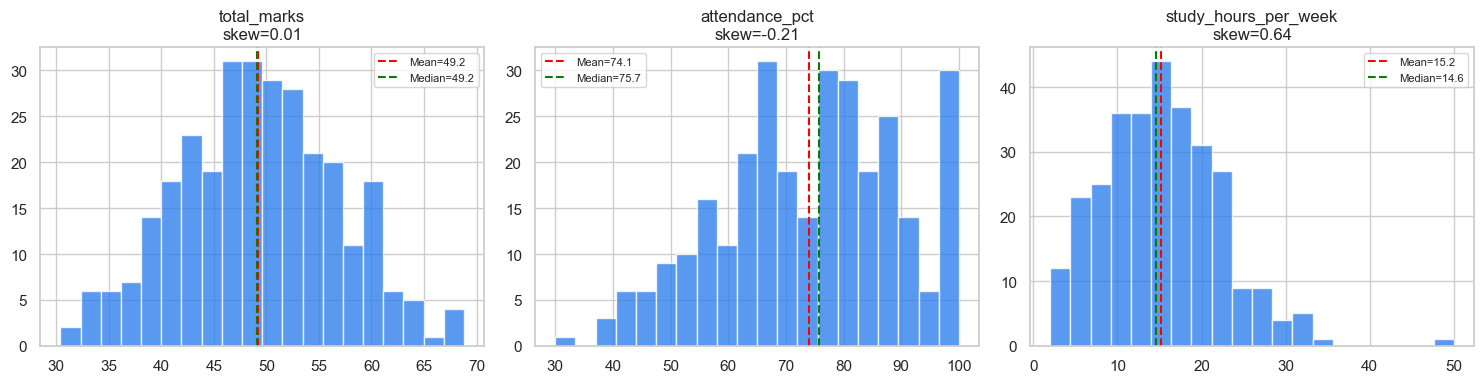

In [50]:
# Visual: histogram with skewness
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["total_marks", "attendance_pct", "study_hours_per_week"]):
    ax.hist(df[col], bins=20, color="#2F80ED", edgecolor="white", alpha=0.8)
    ax.axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean={df[col].mean():.1f}")
    ax.axvline(df[col].median(), color="green", linestyle="--", label=f"Median={df[col].median():.1f}")
    ax.set_title(f"{col}\nskew={df[col].skew():.2f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In a symmetric distribution, mean and median are close. When skewed, mean gets pulled toward the tail.

### 10f. Covariance

**Covariance** tells you whether two variables move together (positive) or in opposite directions (negative).

Formula: $\text{Cov}(X, Y) = \frac{1}{n} \sum (x_i - \bar{x})(y_i - \bar{y})$

Problem with covariance: its value depends on the scale of the variables (hard to interpret the number).

In [51]:
# Worked example with small data
study = np.array([5, 10, 15, 20, 25])
exam = np.array([40, 50, 55, 70, 80])

study_diff = study - study.mean()
exam_diff = exam - exam.mean()
products = study_diff * exam_diff

worked = pd.DataFrame({
    "study_hours": study,
    "exam_marks": exam,
    "study - mean": study_diff,
    "exam - mean": exam_diff,
    "product": products,
})
print(worked)
print(f"\nCovariance = mean of products = {products.mean():.1f}")
print(f"Verify: np.cov gives {np.cov(study, exam, ddof=0)[0,1]:.1f}")
print("\nPositive covariance -> they move in the same direction")

   study_hours  exam_marks  study - mean  exam - mean  product
0            5          40         -10.0        -19.0    190.0
1           10          50          -5.0         -9.0     45.0
2           15          55           0.0         -4.0     -0.0
3           20          70           5.0         11.0     55.0
4           25          80          10.0         21.0    210.0

Covariance = mean of products = 100.0
Verify: np.cov gives 100.0

Positive covariance -> they move in the same direction


### 10g. Correlation

**Correlation** = standardized covariance. Always between -1 and +1.

$r = \frac{\text{Cov}(X, Y)}{\text{Std}(X) \times \text{Std}(Y)}$

| r value | Strength |
|---|---|
| 0.0 to 0.3 | Weak |
| 0.3 to 0.7 | Moderate |
| 0.7 to 1.0 | Strong |

**Correlation does not prove causation.** Two things can be correlated without one causing the other.

In [52]:
# Correlation from our worked example
r_manual = products.mean() / (study.std() * exam.std())
print(f"Manual correlation: {r_manual:.3f}")
print(f"NumPy correlation:  {np.corrcoef(study, exam)[0,1]:.3f}")

Manual correlation: 0.990
NumPy correlation:  0.990


In [53]:
# Correlation matrix for our student data
num_cols = ["attendance_pct", "study_hours_per_week", "assignment_score",
            "lab_score", "internal_marks", "final_exam_marks", "total_marks"]

corr_matrix = df[num_cols].corr().round(3)
corr_matrix

,attendance_pct,study_hours_per_week,assignment_score,lab_score,internal_marks,final_exam_marks,total_marks
attendance_pct,1.000,-0.038,0.090,-0.043,0.034,0.461,0.320
study_hours_per_week,-0.038,1.000,-0.011,-0.018,-0.039,0.384,0.211
assignment_score,0.090,-0.011,1.000,0.128,0.040,0.346,0.738
lab_score,-0.043,-0.018,0.128,1.000,-0.044,-0.010,0.329
internal_marks,0.034,-0.039,0.040,-0.044,1.000,0.012,0.294
final_exam_marks,0.461,0.384,0.346,-0.010,0.012,1.000,0.772
total_marks,0.320,0.211,0.738,0.329,0.294,0.772,1.000


In [54]:
# Key relationships
pairs = [
    ("study_hours_per_week", "final_exam_marks"),
    ("attendance_pct", "final_exam_marks"),
    ("assignment_score", "total_marks"),
]

for x, y in pairs:
    r = df[x].corr(df[y])
    strength = "weak" if abs(r) < 0.3 else "moderate" if abs(r) < 0.7 else "strong"
    direction = "positive" if r > 0 else "negative"
    print(f"{x} vs {y}: r = {r:.3f} ({strength} {direction})")

study_hours_per_week vs final_exam_marks: r = 0.384 (moderate positive)
attendance_pct vs final_exam_marks: r = 0.461 (moderate positive)
assignment_score vs total_marks: r = 0.738 (strong positive)


### 10h. Grouped statistics

Overall averages can hide important differences. The overall average might be 50, but CSE averages 60 and ME averages 40. Grouping reveals what the overall number hides.

In [55]:
# Department-level summary
dept_stats = df.groupby("department")["total_marks"].agg(
    count="count", mean="mean", median="median", std="std", min="min", max="max"
).round(2).sort_values("mean", ascending=False)

dept_stats

,count,mean,median,std,min,max
department,,,,,,
ME,61,50.80,51.80,7.97,34.1,67.1
EEE,29,49.31,48.30,6.36,33.1,63.9
CE,50,49.28,49.60,8.03,32.1,61.3
CSE,76,48.68,48.55,7.18,32.8,66.9
ECE,84,48.43,47.90,7.63,30.4,68.8


In [56]:
# Gender-level summary
df.groupby("gender")[["total_marks", "study_hours_per_week", "attendance_pct"]].agg(
    ["mean", "median"]
).round(2)

total_marks        study_hours_per_week        attendance_pct       
              mean median                 mean median           mean median
gender                                                                     
Female       49.28   49.5                14.95   14.8          76.05   77.7
Male         49.13   48.9                15.34   14.6          72.27   72.6

### 10i. describe() as a statistics dashboard

Instead of writing 8 separate calculations, one command gives you count, mean, std, min, percentiles, and max. It's your statistics dashboard — the first thing experienced data scientists run on a new dataset.

In [57]:
# describe() gives count, mean, std, min, 25%, 50%, 75%, max in one call
df[num_cols].describe().round(2)

,attendance_pct,study_hours_per_week,assignment_score,lab_score,internal_marks,final_exam_marks,total_marks
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,74.07,15.15,65.59,61.30,30.68,48.00,49.20
std,15.53,6.92,18.09,14.51,8.52,11.43,7.54
min,30.00,2.00,19.70,16.50,7.40,14.00,30.40
25%,64.20,10.17,54.25,51.62,25.90,40.72,43.80
50%,75.70,14.60,65.40,62.30,30.60,48.60,49.15
75%,85.78,19.92,79.22,69.90,36.20,55.40,54.60
max,100.00,50.00,100.00,96.60,50.00,76.20,68.80


Reading `describe()`: count shows completeness, std shows spread, 50% is the median, and min/max show the range. Compare 25% and 75% to understand where most students fall.

---
## Step 11: Visualization

Charts answer questions visually. Choose the right chart for the right question.

| Question | Chart |
|---|---|
| Compare group averages | Bar chart |
| See distribution | Histogram |
| Compare spread across groups | Box plot |
| See relationship between 2 numbers | Scatter plot |
| Count categories | Count plot |
| See trend over ordered values | Line chart |

### 11a. Bar chart: Average marks by department

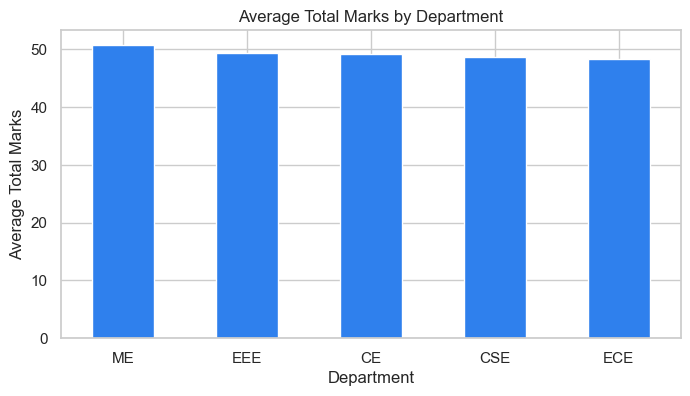

Highest: ME (50.8)
Lowest:  ECE (48.4)


In [58]:
dept_means = df.groupby("department")["total_marks"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
dept_means.plot(kind="bar", color="#2F80ED")
plt.title("Average Total Marks by Department")
plt.xlabel("Department")
plt.ylabel("Average Total Marks")
plt.xticks(rotation=0)
plt.show()

print(f"Highest: {dept_means.idxmax()} ({dept_means.max():.1f})")
print(f"Lowest:  {dept_means.idxmin()} ({dept_means.min():.1f})")

### 11b. Count plot: Students per department and gender

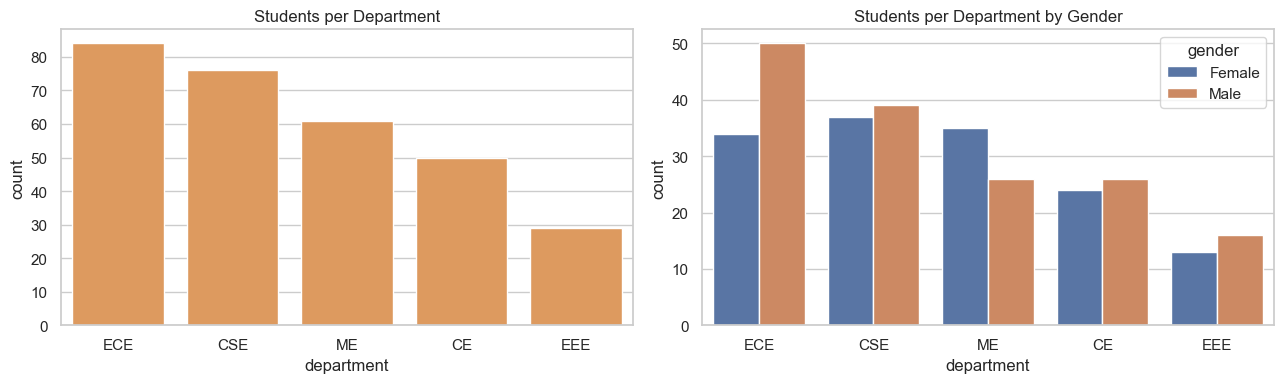

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(data=df, x="department", order=df["department"].value_counts().index,
              color="#F2994A", ax=axes[0])
axes[0].set_title("Students per Department")

sns.countplot(data=df, x="department", hue="gender",
              order=df["department"].value_counts().index, ax=axes[1])
axes[1].set_title("Students per Department by Gender")

plt.tight_layout()
plt.show()

### 11c. Histogram: Marks distribution + skewness

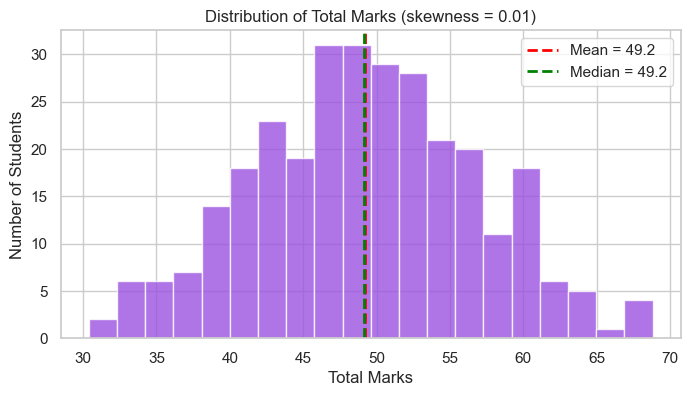

In [60]:
plt.figure(figsize=(8, 4))
plt.hist(df["total_marks"], bins=20, color="#9B51E0", edgecolor="white", alpha=0.8)
plt.axvline(df["total_marks"].mean(), color="red", linestyle="--", linewidth=2, label=f"Mean = {df['total_marks'].mean():.1f}")
plt.axvline(df["total_marks"].median(), color="green", linestyle="--", linewidth=2, label=f"Median = {df['total_marks'].median():.1f}")
plt.title(f"Distribution of Total Marks (skewness = {df['total_marks'].skew():.2f})")
plt.xlabel("Total Marks")
plt.ylabel("Number of Students")
plt.legend()
plt.show()

### 11d. Box plot: Marks by department

C:\Users\nagcl\AppData\Local\Temp\ipykernel_28812\279578825.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="department", y="total_marks",


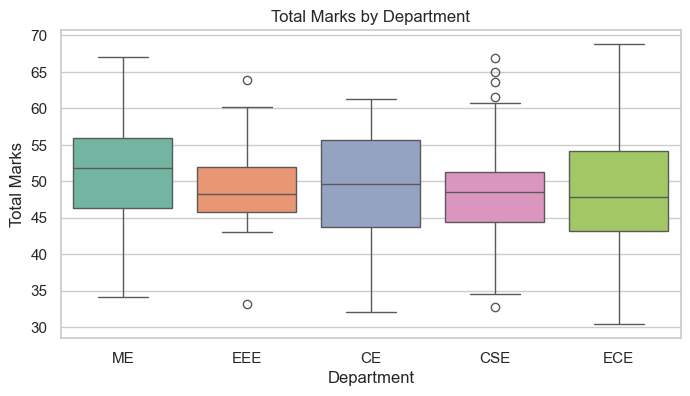

Box = middle 50% (IQR). Line inside = median. Dots = outliers.


In [61]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="department", y="total_marks",
            order=dept_means.index, palette="Set2")
plt.title("Total Marks by Department")
plt.xlabel("Department")
plt.ylabel("Total Marks")
plt.show()

print("Box = middle 50% (IQR). Line inside = median. Dots = outliers.")

### 11e. Scatter plot: Study hours vs Final exam marks

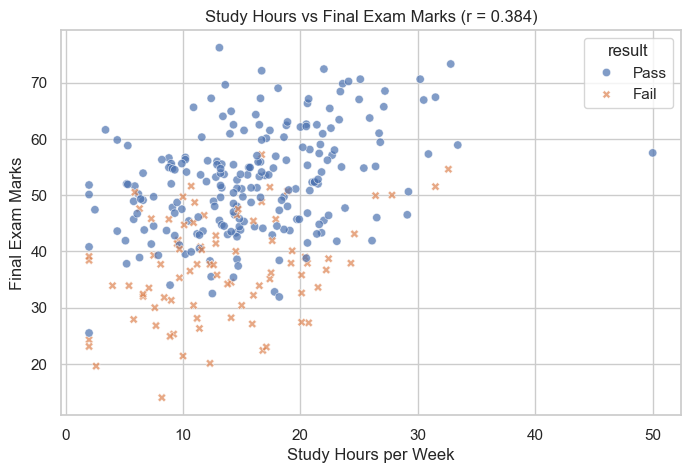

Correlation: 0.384 — association, not causation.


In [62]:
r_study_exam = df["study_hours_per_week"].corr(df["final_exam_marks"])

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="study_hours_per_week", y="final_exam_marks",
                hue="result", style="result", alpha=0.7)
plt.title(f"Study Hours vs Final Exam Marks (r = {r_study_exam:.3f})")
plt.xlabel("Study Hours per Week")
plt.ylabel("Final Exam Marks")
plt.show()

print(f"Correlation: {r_study_exam:.3f} — association, not causation.")

### 11f. Line chart: Average marks by semester

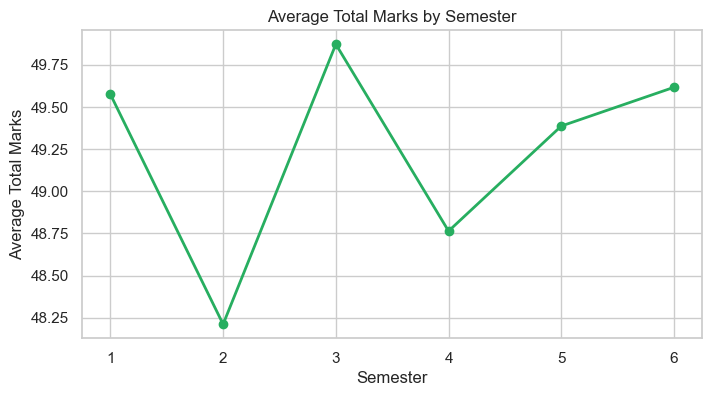

In [63]:
sem_trend = df.groupby("semester")["total_marks"].mean().sort_index()

plt.figure(figsize=(8, 4))
plt.plot(sem_trend.index, sem_trend.values, marker="o", color="#27AE60", linewidth=2)
plt.title("Average Total Marks by Semester")
plt.xlabel("Semester")
plt.ylabel("Average Total Marks")
plt.xticks(sem_trend.index)
plt.show()

---
## Step 12: Feature Preparation

ML models only understand numbers, and they're sensitive to scale. A column ranging 0–100 will dominate one ranging 0–1. Text categories like "CSE" mean nothing to an algorithm. Feature preparation translates human-readable data into model-ready data.

- **New features:** Combine existing columns into useful ratios
- **Scaling:** Put numeric columns on comparable scales
- **Encoding:** Convert text categories to numbers

### 12a. New features

Sometimes the most useful information isn't in any single column but in the relationship between columns. Combining existing columns can reveal patterns the raw data doesn't show directly.

In [64]:
# Total score combining all assessments
df["total_score"] = (df["assignment_score"] + df["lab_score"] + df["internal_marks"] + df["final_exam_marks"]).round(1)

# Performance ratio: how much of their potential did they achieve?
df["performance_ratio"] = (df["final_exam_marks"] / df["total_score"] * 100).round(1)

df[["name", "assignment_score", "lab_score", "internal_marks", "final_exam_marks",
    "total_score", "performance_ratio"]].head()

,name,assignment_score,lab_score,internal_marks,final_exam_marks,total_score,performance_ratio
0,Sara,46.0,67.0,38.0,48.9,199.9,24.5
1,Kiran,64.3,67.3,28.7,43.3,203.6,21.3
2,Tanvi,48.4,65.2,38.9,56.9,209.4,27.2
3,Kavya,86.1,70.1,22.7,55.4,234.3,23.6
4,Priya,49.5,56.7,21.3,48.7,176.2,27.6


### 12b. Standard Scaling

If attendance is 0–100 and study_hours is 0–40, a model might think attendance is more important just because the numbers are bigger. Scaling puts all features on the same playing field.

Result: mean ~ 0, std ~ 1. Tells you how many standard deviations each value is from average.

In [65]:
scale_cols = ["attendance_pct", "study_hours_per_week", "assignment_score",
              "lab_score", "internal_marks", "final_exam_marks"]

scaler = StandardScaler()
scaled = pd.DataFrame(
    scaler.fit_transform(df[scale_cols]),
    columns=[c + "_scaled" for c in scale_cols],
    index=df.index
).round(3)

print("Scaled data (first 5 rows):")
scaled.head()

Scaled data (first 5 rows):


,attendance_pct_scaled,study_hours_per_week_scaled,assignment_score_scaled,lab_score_scaled,internal_marks_scaled,final_exam_marks_scaled
0,1.621,-1.353,-1.085,0.394,0.861,0.079
1,-1.533,-0.095,-0.072,0.414,-0.233,-0.412
2,1.672,0.397,-0.952,0.269,0.967,0.780
3,0.918,-0.124,1.135,0.608,-0.939,0.649
4,0.318,-0.601,-0.891,-0.317,-1.103,0.061


In [66]:
# Verify: mean ~ 0, std ~ 1
print("Verification (should be mean~0, std~1):")
scaled.describe().loc[["mean", "std"]].round(3)

Verification (should be mean~0, std~1):


,attendance_pct_scaled,study_hours_per_week_scaled,assignment_score_scaled,lab_score_scaled,internal_marks_scaled,final_exam_marks_scaled
mean,0.000,-0.000,0.000,-0.000,0.000,0.000
std,1.002,1.002,1.002,1.002,1.002,1.002


### 12c. Min-Max Normalization

Some algorithms (especially neural networks) work best when all inputs are in the same bounded range. Min-Max squeezes everything into [0, 1].

Result: values between 0 and 1. 0 = minimum, 1 = maximum.

In [67]:
normalizer = MinMaxScaler()
normalized = pd.DataFrame(
    normalizer.fit_transform(df[scale_cols]),
    columns=[c + "_norm" for c in scale_cols],
    index=df.index
).round(3)

print("Normalized data (first 5 rows):")
normalized.head()

Normalized data (first 5 rows):


,attendance_pct_norm,study_hours_per_week_norm,assignment_score_norm,lab_score_norm,internal_marks_norm,final_exam_marks_norm
0,0.989,0.079,0.328,0.630,0.718,0.561
1,0.290,0.260,0.555,0.634,0.500,0.471
2,1.000,0.331,0.357,0.608,0.739,0.690
3,0.833,0.256,0.827,0.669,0.359,0.666
4,0.700,0.188,0.371,0.502,0.326,0.558


### Scaling vs Normalization

| Method | Result | When to use |
|---|---|---|
| Standard Scaling | Mean~0, Std~1 | When algorithms assume normal distribution (e.g., SVM, logistic regression) |
| Min-Max Normalization | 0 to 1 | When you need bounded values (e.g., neural networks) |

### 12d. One-Hot Encoding

Convert text categories into 0/1 columns. Use when categories have **no natural order**.

In [68]:
# One-hot encode department
dept_encoded = pd.get_dummies(df["department"], prefix="dept", dtype=int)
print("Department one-hot encoding:")
dept_encoded.head()

Department one-hot encoding:


,dept_CE,dept_CSE,dept_ECE,dept_EEE,dept_ME
0,0,0,0,1,0
1,0,0,1,0,0
2,0,0,0,0,1
3,0,0,1,0,0
4,0,0,1,0,0


In [69]:
# One-hot encode city
city_encoded = pd.get_dummies(df["city"], prefix="city", dtype=int)
print("City one-hot encoding:")
city_encoded.head()

City one-hot encoding:


,city_Bangalore,city_Chennai,city_Delhi,city_Hyderabad,city_Mumbai
0,0,0,0,1,0
1,0,0,0,0,1
2,0,0,1,0,0
3,0,0,1,0,0
4,0,0,0,0,1


### 12e. Ordered Mapping

Use when categories **have a meaningful order**.

In [70]:
# Result has an order: Fail < Pass < Distinction
result_map = {"Fail": 0, "Pass": 1, "Distinction": 2}
df["result_numeric"] = df["result"].map(result_map)

df[["name", "result", "result_numeric"]].head(10)

,name,result,result_numeric
0,Sara,Pass,1
1,Kiran,Pass,1
2,Tanvi,Pass,1
3,Kavya,Pass,1
4,Priya,Fail,0
5,Vikram,Fail,0
6,Tanvi,Fail,0
7,Divya,Pass,1
8,Sara,Pass,1
9,Varun,Pass,1


### Encoding decision guide

| Situation | Method | Example |
|---|---|---|
| No natural order | One-hot encoding | department, city |
| Meaningful order | Ordered mapping | Fail < Pass < Distinction |
| Binary (2 values) | 0/1 mapping | gender (Male=0, Female=1) |
| IDs and names | Don't encode | student_id, name |

---
## Step 13: Communication & Decision

Data Science is incomplete without communicating findings.

A good report has: **findings + evidence + caution + recommendation**

In [71]:
# Summary table
r_study = df["study_hours_per_week"].corr(df["final_exam_marks"])
r_att = df["attendance_pct"].corr(df["final_exam_marks"])

summary = pd.DataFrame({
    "metric": [
        "Total students (after cleaning)",
        "Pass rate",
        "Distinction rate",
        "Mean total marks",
        "Median total marks",
        "Top department (avg marks)",
        "Study hours vs exam corr",
        "Attendance vs exam corr",
    ],
    "value": [
        len(df),
        f"{(df['result'] != 'Fail').mean()*100:.1f}%",
        f"{(df['result'] == 'Distinction').mean()*100:.1f}%",
        f"{df['total_marks'].mean():.1f}",
        f"{df['total_marks'].median():.1f}",
        dept_means.idxmax(),
        f"{r_study:.3f}",
        f"{r_att:.3f}",
    ],
})

summary

,metric,value
0,Total students (after cleaning),300
1,Pass rate,71.3%
2,Distinction rate,0.0%
3,Mean total marks,49.2
4,Median total marks,49.2
5,Top department (avg marks),ME
6,Study hours vs exam corr,0.384
7,Attendance vs exam corr,0.461


In [72]:
# Final report
report = f"""DAY 1 EDA REPORT: STUDENT PERFORMANCE
{'='*50}

DATASET: {len(df)} students, {df.shape[1]} columns (cleaned from {len(raw)} raw rows)

FINDINGS:
1. {dept_means.idxmax()} department has the highest average marks ({dept_means.max():.1f}).
2. {(df['result']=='Fail').sum()} students failed ({(df['result']=='Fail').mean()*100:.1f}% fail rate).
3. Study hours and exam marks are correlated (r={r_study:.3f}).
4. Attendance and exam marks are correlated (r={r_att:.3f}).
5. Median total marks: {df['total_marks'].median():.1f} (half of students score below this).

EVIDENCE:
- Bar chart shows clear differences between departments.
- Scatter plot shows study hours relate to exam performance.
- Box plots reveal different spreads in each department.

RECOMMENDATION:
- Focus support on students with low attendance and few study hours.
- Investigate what makes top departments successful — share practices.
- Build a predictive model to identify at-risk students early (Day 2).

CAUTION:
- Synthetic dataset. Real-world data may show different patterns.
- Correlation is not causation — studying more is associated with
  better marks, but other factors may explain both.
- Small variations between groups may not be statistically significant.
"""

print(report)

DAY 1 EDA REPORT: STUDENT PERFORMANCE

DATASET: 300 students, 18 columns (cleaned from 303 raw rows)

FINDINGS:
1. ME department has the highest average marks (50.8).
2. 86 students failed (28.7% fail rate).
3. Study hours and exam marks are correlated (r=0.384).
4. Attendance and exam marks are correlated (r=0.461).
5. Median total marks: 49.2 (half of students score below this).

EVIDENCE:
- Bar chart shows clear differences between departments.
- Scatter plot shows study hours relate to exam performance.
- Box plots reveal different spreads in each department.

RECOMMENDATION:
- Focus support on students with low attendance and few study hours.
- Investigate what makes top departments successful — share practices.
- Build a predictive model to identify at-risk students early (Day 2).

CAUTION:
- Synthetic dataset. Real-world data may show different patterns.
- Correlation is not causation — studying more is associated with
  better marks, but other factors may explain both.
- Small 

---
## Lifecycle Recap

| Step | What we did | Key tool |
|---|---|---|
| 1. Problem Understanding | Framed business and data questions | Thinking |
| 2. Data Collection | Created student dataset with real-world problems | `pd.DataFrame()` |
| 3. Data Understanding | Inspected shape, types, values, problems | `.shape`, `.info()`, `.unique()`, `.isna()` |
| 4. Data Cleaning | Fixed text, duplicates, missing, invalid | `.str.strip()`, `.fillna()`, `.drop_duplicates()` |
| 5. EDA | Filtered, sorted, grouped, explored | `.value_counts()`, `.groupby()`, `.sort_values()` |
| 6. Statistics | Center, spread, percentiles, skewness, covariance, correlation | `.mean()`, `.std()`, `.skew()`, `.corr()` |
| 7. Visualization | Bar, count, histogram, box, scatter, line | `matplotlib`, `seaborn` |
| 8. Feature Preparation | New features, scaling, encoding | `StandardScaler`, `get_dummies()`, `.map()` |
| 9. Communication | Report with findings + evidence + caution | Plain English |

**Remember:** Data Science is **iterative**. You will revisit earlier steps as you learn more. That's not a mistake — it's the process working correctly.

---

**Next: Day 2 - Predicting marks from student data (Supervised Learning: Regression)**

We'll use the same cleaned dataset to predict `final_exam_marks` from attendance, study hours, and scores.